# Zadanie 1 — Połączenie z danymi i eksploracja

Cel: załadować dane ze wszystkich źródeł (CSV, AWS S3, Snowflake), zbadać je opisowo i zidentyfikować bbox obszaru analizy.

## 1.0 Importy i konfiguracja

In [1]:
import json
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from shapely import wkt
import warnings
warnings.filterwarnings('ignore')

# Wczytanie credentiali
with open('../credentials/credentials.json') as f:
    creds = json.load(f)

print('Credentiale wczytane.')

Credentiale wczytane.


## 1.1 Wczytanie plików CSV

In [2]:
locations = pd.read_csv('../dane/ds_locations.csv')
competitors = pd.read_csv('../dane/ds_competitors.csv')
poi = pd.read_csv('../dane/ds_poi.csv')
area_df = pd.read_csv('../dane/ds_analysis_area.csv')
districts = pd.read_csv('../dane/ds_districts.csv')

print(f'Lokalizacje klienta:  {len(locations)} rekordów')
print(f'Konkurencja: {len(competitors)} rekordów')
print(f'POI: {len(poi)} rekordów')
print(f'Dzielnice: {len(districts)} rekordów')

Lokalizacje klienta:  50 rekordów
Konkurencja: 98 rekordów
POI: 335 rekordów
Dzielnice: 15 rekordów


In [3]:
# Parsowanie geometrii WKT
area_poly = wkt.loads(area_df['geometry'].iloc[0])
bbox = area_poly.bounds  # (minx, miny, maxx, maxy) = (lng_min, lat_min, lng_max, lat_max)
lng_min, lat_min, lng_max, lat_max = bbox
print(f'Obszar analizy: {area_df["area_name"].iloc[0]}')
print(f'Bbox: lng [{lng_min:.4f}, {lng_max:.4f}], lat [{lat_min:.4f}, {lat_max:.4f}]')

districts_gdf = gpd.GeoDataFrame(
    districts,
    geometry=gpd.GeoSeries.from_wkt(districts['geometry']),
    crs=4326
)

locations_gdf = gpd.GeoDataFrame(
    locations,
    geometry=gpd.points_from_xy(locations.lng, locations.lat),
    crs=4326
)

Obszar analizy: Silesia-Kraków Metropolitan Area
Bbox: lng [18.5400, 20.1200], lat [49.9600, 50.4800]


## 1.2 EDA — lokalizacje klienta (target)

In [4]:
locations.describe()

,lat,lng,monthly_revenue
count,50.000000,50.000000,50.000000
mean,50.189476,19.301192,275269.401400
std,0.122854,0.521044,108052.296936
min,49.965208,18.548470,50000.000000
25%,50.096988,18.900723,204756.427500
50%,50.214888,19.061025,260956.905000
75%,50.287100,19.925615,318203.880000
max,50.441998,20.081011,623866.240000


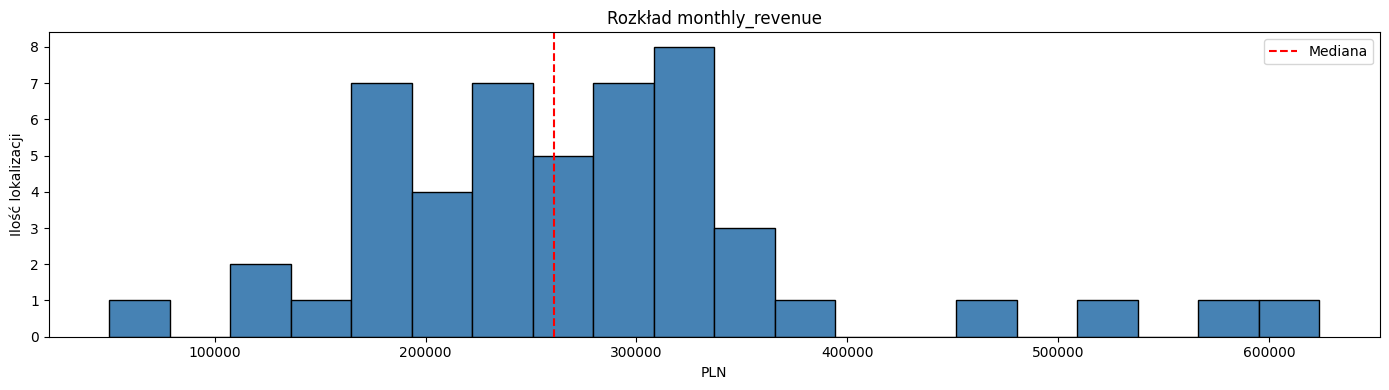


Najniższe przychody:
   location_id  monthly_revenue
32     LOC_033         50000.00
37     LOC_038        121446.26
39     LOC_040        130489.86
7      LOC_008        156433.13
29     LOC_030        167860.76


In [5]:

plt.figure(figsize=(14, 4))

plt.hist(locations['monthly_revenue'], bins=20, edgecolor='black', color='steelblue')
plt.title('Rozkład monthly_revenue')
plt.xlabel('PLN')
plt.ylabel("Ilość lokalizacji")

plt.axvline(locations['monthly_revenue'].median(),
            color='red', linestyle='--', label='Mediana')
plt.legend()

plt.tight_layout()
plt.show()

# Podejrzany outlier
print('\nNajniższe przychody:')
print(locations.nsmallest(5, 'monthly_revenue')[['location_id', 'monthly_revenue']])

## 1.3 EDA — konkurencja i POI

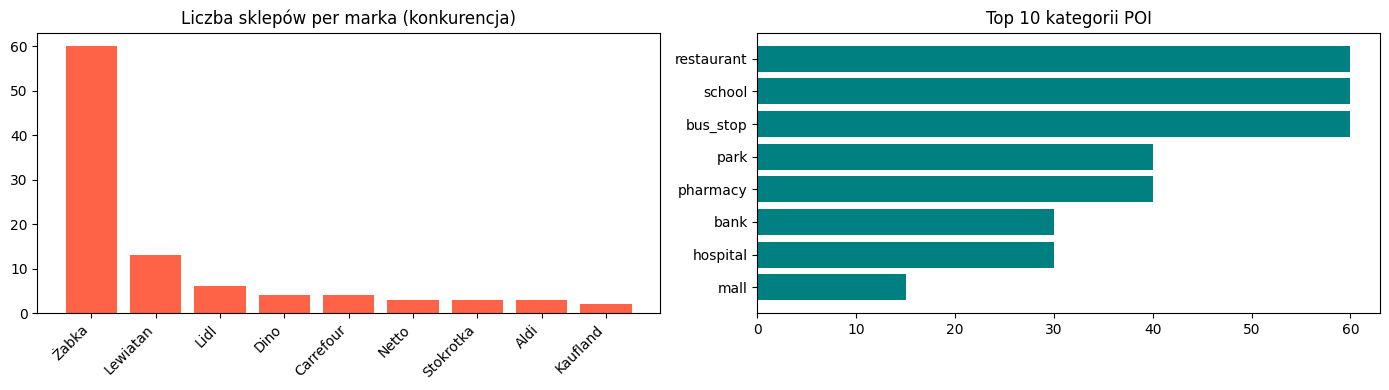

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

brand_counts = competitors['brand'].value_counts()
axes[0].bar(brand_counts.index, brand_counts.values, color='tomato')
axes[0].set_title('Liczba sklepów per marka (konkurencja)')
axes[0].set_xticklabels(brand_counts.index, rotation=45, ha='right')

poi_counts = poi['category'].value_counts().head(10)
axes[1].barh(poi_counts.index[::-1], poi_counts.values[::-1], color='teal')
axes[1].set_title('Top 10 kategorii POI')

plt.tight_layout()
plt.show()

## 1.4 Pobranie danych z AWS S3

In [7]:
import boto3
import os

aws = creds['aws']
s3 = boto3.client(
    's3',
    region_name=aws['region'],
    aws_access_key_id=aws['access_key_id'],
    aws_secret_access_key=aws['secret_access_key']
)

os.makedirs('../data/raw', exist_ok=True)

files_to_download = [
    ('DATA_ENGINEER/recruitment_buildings.csv.gz',  '../data/raw/buildings.csv.gz'),
    ('DATA_ENGINEER/recruitment_population.csv.gz', '../data/raw/population.csv.gz'),
]

for s3_key, local_path in files_to_download:
    if not os.path.exists(local_path):
        print(f'Pobieranie {s3_key}...')
        s3.download_file(aws['bucket'], s3_key, local_path)
        print(f'  -> Zapisano do {local_path}')
    else:
        print(f'{local_path} już istnieje, pomijam.')

../data/raw/buildings.csv.gz już istnieje, pomijam.
../data/raw/population.csv.gz już istnieje, pomijam.


In [8]:
buildings = pd.read_csv('../data/raw/buildings.csv.gz',  compression='gzip')
population = pd.read_csv('../data/raw/population.csv.gz', compression='gzip')

print(f'Budynki: {len(buildings):,} rekordów, kolumny: {list(buildings.columns)}')
print(f'Populacja: {len(population):,} rekordów, kolumny: {list(population.columns)}')

Budynki: 955,612 rekordów, kolumny: ['teryt', 'lokalnyid', 'funogolnabudynku_desc', 'funszczegolowabudynku_desc', 'area', 'geometry', 'geojson', 'geohash5']
Populacja: 450,140 rekordów, kolumny: ['id', 'teryt', 'city', 'street', 'housenumber', 'households', 'household_size', 'total', 'male', 'female', 'lat', 'lng']


In [ ]:
within_bbox = (
    population['lat'].between(lat_min, lat_max) &
    population['lng'].between(lng_min, lng_max)
)
n_outside = (~within_bbox).sum()
assert n_outside == 0, f'Oczekiwano pliku prefiltrowanego, ale {n_outside:,} rekordów poza bboksem'
print(f'Populacja: {len(population):,} rekordów (100% w bboksie obszaru analizy)')

# Sanity-check: zerowe gospodarstwa i ekstremalne household_size (te odfiltrujemy w nb02)
n_zero_total      = (population['total'] == 0).sum()
n_extreme_hh_size = ((population['household_size'] <= 0) | (population['household_size'] > 10)).sum()
print(f'  • rekordów z total=0:                  {n_zero_total:,} ({n_zero_total/len(population):.1%})')
print(f'  • rekordów z household_size poza (0,10]: {n_extreme_hh_size:,} ({n_extreme_hh_size/len(population):.1%})')

# Agregat per miasto — pokazuje jak rozkład populacji wygląda względem 50 sklepów treningowych
city_summary = (
    population.groupby('city')
    .agg(rekordow=('total', 'size'),
         populacja=('total', 'sum'),
         gospodarstwa=('households', 'sum'))
    .sort_values('populacja', ascending=False)
    .head(10)
)
print('\nTop 10 miast wg populacji w obszarze analizy:')
print(city_summary.to_string())

# Statystyki opisowe (po wykluczeniu rekordów z total=0 — niestabilizują rozkład)
print('\nStatystyki opisowe (rekordy z total > 0):')
print(population[population['total'] > 0][
    ['total', 'male', 'female', 'households', 'household_size']
].describe().round(2))

Populacja: 450,140 rekordów (100% w bboksie obszaru analizy)
  • rekordów z total=0:                  40,316 (9.0%)
  • rekordów z household_size poza (0,10]: 46,723 (10.4%)

Top 10 miast wg populacji w obszarze analizy:
                  rekordow  populacja  gospodarstwa
city                                               
KRAKÓW               37128   686080.0      226919.0
KATOWICE             21410   252690.0      109594.0
SOSNOWIEC            13685   174628.0       76172.0
GLIWICE              15992   156202.0       65057.0
ZABRZE               12502   142326.0       58431.0
BYTOM                 9088   131157.0       56948.0
RUDA ŚLĄSKA          10371   121661.0       50076.0
TYCHY                10661   113150.0       44391.0
DĄBROWA GÓRNICZA     11617   106603.0       42817.0
CHORZÓW               5540    88556.0       40661.0

Statystyki opisowe (rekordy z total > 0):
           total       male     female  households  household_size
count  409824.00  409824.00  409824.00    409

In [10]:
# Typy zabudowy
print('Top typy zabudowy (ogólne):')
print(buildings['funogolnabudynku_desc'].value_counts().head(10))

Top typy zabudowy (ogólne):
funogolnabudynku_desc
budynkiMieszkalneJednorodzinne       453932
budynekGospodarstwaRolnego           289208
budynkiOTrzechIWiecejMieszkaniach     65376
budynkiODwochMieszkaniach             33738
budynkiGarazy                         25812
budynkiHandlowoUslugowe               23157
budynkiPrzemyslowe                    18989
zbiornikSilosIBudynkiMagazynowe       12841
budynkiBiurowe                        12410
budynkiSzkolIInstytucjiBadawczych      5138
Name: count, dtype: int64


## 1.5 Połączenie ze Snowflake i eksploracja RECRUITMENT_TRACES

In [11]:
import snowflake.connector

sf = creds['snowflake']
conn = snowflake.connector.connect(
    account=sf['account'],
    user=sf['user'],
    password=sf['password'],
    warehouse=sf['warehouse'],
    database=sf['database'],
    schema=sf['schema'],
    role=sf['role']
)
cur = conn.cursor()
print('Połączono ze Snowflake.')

Połączono ze Snowflake.


In [12]:
# Schemat tabeli
cur.execute('DESCRIBE TABLE RECRUITMENT_TRACES')
schema = cur.fetchall()
for row in schema:
    print(row[0], '-', row[1])

OCCURED_AT - VARCHAR(16777216)
APP_ID - VARCHAR(16777216)
PROXI_USER_ID - VARCHAR(16777216)
LATITUDE - VARCHAR(16777216)
LONGITUDE - VARCHAR(16777216)
GEOHASH - VARCHAR(16777216)
PAIRING_ID - VARCHAR(16777216)
MAC_ADDRESS - VARCHAR(16777216)
RSSI - VARCHAR(16777216)


In [13]:
# Podstawowe statystyki
cur.execute('''
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN TRY_TO_TIMESTAMP_NTZ(occured_at) IS NULL THEN 1 ELSE 0 END) AS invalid_rows,
    MIN(CASE WHEN TRY_TO_TIMESTAMP_NTZ(occured_at) BETWEEN '2020-07-01' AND '2020-08-01'
             THEN TRY_TO_TIMESTAMP_NTZ(occured_at) END) AS earliest,
    MAX(CASE WHEN TRY_TO_TIMESTAMP_NTZ(occured_at) BETWEEN '2020-07-01' AND '2020-08-01'
             THEN TRY_TO_TIMESTAMP_NTZ(occured_at) END) AS latest
FROM RECRUITMENT_TRACES
''')
row = cur.fetchone()
print(f'Łączna liczba wierszy:  {row[0]:,}')
print(f'Błędne wiersze (śmieć): {row[1]:,} ({row[1]/row[0]*100:.4f}%)')
print(f'Zakres dat (lipiec 2020): {row[2]} — {row[3]}')


Łączna liczba wierszy:  435,591,908
Błędne wiersze (śmieć): 1,425 (0.0003%)
Zakres dat (lipiec 2020): 2020-07-01 00:00:00.002000 — 2020-07-31 18:20:05.976999


In [14]:
# Liczba wierszy w obszarze analizy
cur.execute(f'''
SELECT COUNT(*)
FROM RECRUITMENT_TRACES
WHERE TRY_CAST(latitude AS FLOAT) BETWEEN {lat_min} AND {lat_max}
  AND TRY_CAST(longitude AS FLOAT) BETWEEN {lng_min} AND {lng_max}
''')
count_area = cur.fetchone()[0]
print(f'Traces w obszarze analizy: {count_area:,}')

Traces w obszarze analizy: 12,506,636


In [15]:
# Próbka 1000 wierszy z obszaru
cur.execute(f'''
SELECT occured_at, proxi_user_id,
       TRY_CAST(latitude AS FLOAT)  AS lat,
       TRY_CAST(longitude AS FLOAT) AS lng,
       geohash
FROM RECRUITMENT_TRACES
WHERE TRY_CAST(latitude AS FLOAT) BETWEEN {lat_min} AND {lat_max}
  AND TRY_CAST(longitude AS FLOAT) BETWEEN {lng_min} AND {lng_max}
LIMIT 1000
''')
sample = pd.DataFrame(cur.fetchall(), columns=['occured_at', 'proxi_user_id', 'lat', 'lng', 'geohash'])
print(f'Próbka: {len(sample)} wierszy')
sample.head()

Próbka: 1000 wierszy


,occured_at,proxi_user_id,lat,lng,geohash
0,2020-07-04 22:52:02.025,9131cb7e-0593-4c8e-842c-3410ed6964c7,50.250778,18.677444,u2vmc5b
1,2020-07-04 22:52:02.030999,9131cb7e-0593-4c8e-842c-3410ed6964c7,50.250778,18.677444,u2vmc5b
2,2020-07-04 22:00:09.453,13ac3a19-f601-45e9-8db1-685c53229232,50.143661,18.671951,u2vm2bk
3,2020-07-04 22:00:09.463,13ac3a19-f601-45e9-8db1-685c53229232,50.143661,18.671951,u2vm2bk
4,2020-07-04 21:48:04.306999,ad04f420-f008-4fd2-b0cd-acd388e22a63,50.233526,18.767223,u2vmg09z


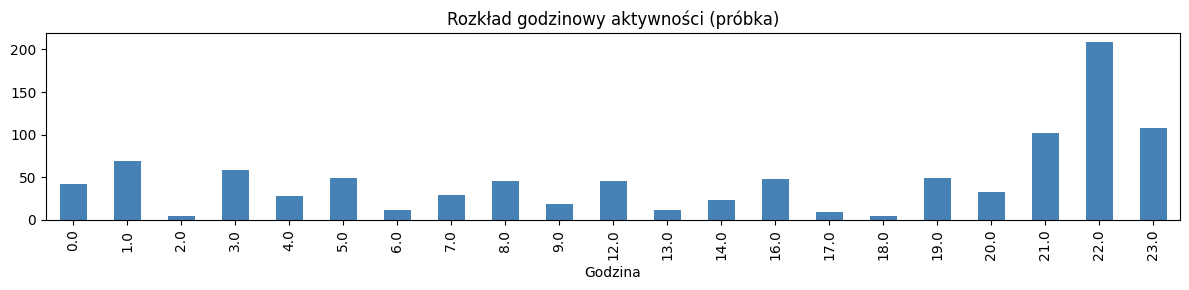

In [16]:
# Rozkład godzinowy ruchu (z próbki)
sample['hour'] = pd.to_datetime(sample['occured_at'], errors='coerce').dt.hour
sample['hour'].value_counts().sort_index().plot(kind='bar', figsize=(12, 3),
    title='Rozkład godzinowy aktywności (próbka)', color='steelblue')
plt.xlabel('Godzina')
plt.tight_layout()
plt.show()

## 1.6 Mapa poglądowa

In [17]:
center_lat = (lat_min + lat_max) / 2
center_lng = (lng_min + lng_max) / 2

m = folium.Map(location=[center_lat, center_lng], zoom_start=10, tiles='CartoDB positron')

# Obszar analizy
import json as json_lib
area_geojson = {
    'type': 'Feature',
    'geometry': area_poly.__geo_interface__,
    'properties': {}
}
folium.GeoJson(area_geojson, style_function=lambda x: {
    'fillColor': 'transparent', 'color': 'navy', 'weight': 2
}, name='Obszar analizy').add_to(m)

# Sklepy klienta
for _, row in locations.iterrows():
    folium.CircleMarker(
        [row.lat, row.lng], radius=7, color='red', fill=True, fill_opacity=0.8,
        popup=f"{row.location_id}<br>Revenue: {row.monthly_revenue:,.0f} PLN"
    ).add_to(m)

# Konkurencja
brand_colors = {'Żabka': 'blue', 'Lidl': 'yellow', 'Biedronka': 'orange',
                'Aldi': 'purple', 'Dino': 'green', 'Carrefour': 'cadetblue',
                'Kaufland': 'red', 'Netto': 'darkblue', 'Stokrotka': 'lightgreen',
                'Lewiatan': 'pink'}
for _, row in competitors.iterrows():
    color = brand_colors.get(row.brand, 'gray')
    folium.CircleMarker(
        [row.lat, row.lng], radius=4, color=color, fill=True, fill_opacity=0.6,
        popup=row.brand
    ).add_to(m)

folium.LayerControl().add_to(m)
m

In [18]:
cur.close()
conn.close()
print('Połączenie ze Snowflake zamknięte.')

Połączenie ze Snowflake zamknięte.


# Wnioski z eksploracji danych

Po przejrzeniu wszystkich źródeł danych (CSV, S3, Snowflake) wyłaniają się następujące obserwacje, które
ukierunkowują dalszy pipeline.

## Mamy mało danych treningowych, ale dużo danych kontekstowych

Zbiór treningowy to zaledwie 50 lokalizacji klienta z miesięcznym przychodem. To poważne ograniczenie —
wymusza cross-validation zamiast prostego podziału train/test i czyni model wrażliwym na pojedyncze
obserwacje. Kontekst przestrzenny natomiast jest bogaty: 98 sklepów konkurencji, 335 POI, prawie milion
budynków i 414 milionów rekordów ruchu pieszego ze Snowflake.

Obszar analizy to aglomeracja śląsko-krakowska, bbox lng [18.54, 20.12] × lat [49.96, 50.48]. Po
przefiltrowaniu Snowflake do tego obszaru zostaje 12,5 mln traces, co wymaga
batchowania zapytań.

## Przychód jest skośny i ma jednego wyraźnego outliera

Mediana to ~261 tys. PLN, średnia ~275 tys., maksimum 624 tys. Rozkład prawoskośny — typowy dla wartości
biznesowych — uzasadnia transformację `log1p(y)` przed modelowaniem.

Najmocniej rzuca się w oczy **LOC_033 z przychodem 50 tys. PLN**, czyli 4× poniżej kolejnego najniższego
sklepu (121 tys.). To może być nowo otwarty sklep lub błąd danych. Niezależnie
od przyczyny — przy n=50 jeden taki punkt potrafi wyciągnąć całą regresję, więc trzeba raportować metryki
zarówno z nim, jak i bez niego.

## Konkurencję zdominowała Żabka

60 z 98 sklepów konkurencji to Żabki — 61% rynku w obszarze. To znacząca informacja modelowa. Dyskonty (Lidl/Aldi/Netto) zachowują
się inaczej — średnia odległość do najbliższego dyskontu z lokalizacji klienta to ~9 km, więc krótkie
bufory (500–1000 m) dadzą same zera. Dyskonty wymagają bufora 3 km lub cechy ciągłej `dist_nearest_discount`.

## Dane budynkowe wymagają kategoryzacji

Surowy plik z S3 to 955k budynków, ale na liście top kategorii dominują budynki mieszkalne jednorodzinne
(454k) i — co ciekawe — **gospodarstwa rolne (289k, 30% całości)**. Same liczniki "wszystkich budynków" w
buforze wokół lokalizacji mieszałyby więc sygnał miejski z wiejskim. Konieczne jest rozdzielenie na
residential / commercial / industrial / public, a najlepiej ważenie po powierzchni (galeria handlowa = 1
budynek o 80 tys. m², dom = 1 budynek o 100 m² — liczyć powinniśmy powierzchnię, nie sztuki).

## Snowflake — kluczowa optymalizacja zapytań

Tabela RECRUITMENT_TRACES ma 414 milionów wierszy z lipca 2020. Schema trzyma `latitude` i `longitude`
jako VARCHAR, więc każde zapytanie wymaga `TRY_CAST(... AS FLOAT)`. Najważniejsza lekcja praktyczna:
filtr `BETWEEN` na bboksie **musi** wyprzedzać `ST_DISTANCE`, bo policzenie odległości dla 414 mln
wierszy zabija query.

Drugi kontekst, łatwy do przeoczenia: lipiec 2020 to okres COVID-owy, po pierwszym lockdownie. Ruch
pieszy z tego okresu może być niereprezentatywny dla "normalnego" stanu — to ważne zastrzeżenie przy
interpretacji modelu i predykcji whitespotów.
